<a href="https://colab.research.google.com/github/HarshPramodh/Business-Analytics-Projects/blob/main/Fraud_Detection_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from sklearn.model_selection import train_test_split

In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

In [5]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,f1_score,confusion_matrix,classification_report)

In [6]:
df=pd.read_csv("fraudTest.csv")

In [7]:
df.head()

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2020-06-21 12:14:25,2291163933867244,fraud_Kirlin and Sons,personal_care,2.86,Jeff,Elliott,M,351 Darlene Green,...,33.9659,-80.9355,333497,Mechanical engineer,1968-03-19,2da90c7d74bd46a0caf3777415b3ebd3,1371816865,33.986391,-81.200714,0
1,1,2020-06-21 12:14:33,3573030041201292,fraud_Sporer-Keebler,personal_care,29.84,Joanne,Williams,F,3638 Marsh Union,...,40.3207,-110.4360,302,"Sales professional, IT",1990-01-17,324cc204407e99f51b0d6ca0055005e7,1371816873,39.450498,-109.960431,0
2,2,2020-06-21 12:14:53,3598215285024754,"fraud_Swaniawski, Nitzsche and Welch",health_fitness,41.28,Ashley,Lopez,F,9333 Valentine Point,...,40.6729,-73.5365,34496,"Librarian, public",1970-10-21,c81755dbbbea9d5c77f094348a7579be,1371816893,40.495810,-74.196111,0
3,3,2020-06-21 12:15:15,3591919803438423,fraud_Haley Group,misc_pos,60.05,Brian,Williams,M,32941 Krystal Mill Apt. 552,...,28.5697,-80.8191,54767,Set designer,1987-07-25,2159175b9efe66dc301f149d3d5abf8c,1371816915,28.812398,-80.883061,0
4,4,2020-06-21 12:15:17,3526826139003047,fraud_Johnston-Casper,travel,3.19,Nathan,Massey,M,5783 Evan Roads Apt. 465,...,44.2529,-85.0170,1126,Furniture designer,1955-07-06,57ff021bd3f328f8738bb535c302a31b,1371816917,44.959148,-85.884734,0


In [8]:
df.shape

(555719, 23)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 555719 entries, 0 to 555718
Data columns (total 23 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Unnamed: 0             555719 non-null  int64  
 1   trans_date_trans_time  555719 non-null  object 
 2   cc_num                 555719 non-null  int64  
 3   merchant               555719 non-null  object 
 4   category               555719 non-null  object 
 5   amt                    555719 non-null  float64
 6   first                  555719 non-null  object 
 7   last                   555719 non-null  object 
 8   gender                 555719 non-null  object 
 9   street                 555719 non-null  object 
 10  city                   555719 non-null  object 
 11  state                  555719 non-null  object 
 12  zip                    555719 non-null  int64  
 13  lat                    555719 non-null  float64
 14  long                   555719 non-nu

In [10]:
df.describe()

,Unnamed: 0,cc_num,amt,zip,lat,long,city_pop,unix_time,merch_lat,merch_long,is_fraud
count,555719.000000,5.557190e+05,555719.000000,555719.000000,555719.000000,555719.000000,5.557190e+05,5.557190e+05,555719.000000,555719.000000,555719.000000
mean,277859.000000,4.178387e+17,69.392810,48842.628015,38.543253,-90.231325,8.822189e+04,1.380679e+09,38.542798,-90.231380,0.003860
std,160422.401459,1.309837e+18,156.745941,26855.283328,5.061336,13.721780,3.003909e+05,5.201104e+06,5.095829,13.733071,0.062008
min,0.000000,6.041621e+10,1.000000,1257.000000,20.027100,-165.672300,2.300000e+01,1.371817e+09,19.027422,-166.671575,0.000000
25%,138929.500000,1.800429e+14,9.630000,26292.000000,34.668900,-96.798000,7.410000e+02,1.376029e+09,34.755302,-96.905129,0.000000
50%,277859.000000,3.521417e+15,47.290000,48174.000000,39.371600,-87.476900,2.408000e+03,1.380762e+09,39.376593,-87.445204,0.000000
75%,416788.500000,4.635331e+15,83.010000,72011.000000,41.894800,-80.175200,1.968500e+04,1.385867e+09,41.954163,-80.264637,0.000000
max,555718.000000,4.992346e+18,22768.110000,99921.000000,65.689900,-67.950300,2.906700e+06,1.388534e+09,66.679297,-66.952026,1.000000


In [11]:
df.isnull().sum()

,0
Unnamed: 0,0
trans_date_trans_time,0
cc_num,0
merchant,0
category,0
amt,0
first,0
last,0
gender,0
street,0


In [12]:
# Exploratory Data Analysis
df['is_fraud'].value_counts()


,count
is_fraud,
0,553574
1,2145


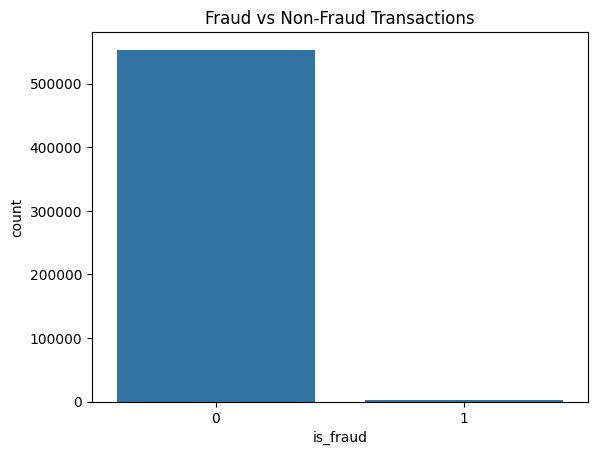

In [13]:
sns.countplot(
    x='is_fraud',
    data=df
)

plt.title('Fraud vs Non-Fraud Transactions')

plt.show()

In [14]:
#Which category has highest frauds
fraud_category = df[df['is_fraud']==1]

fraud_category['category'].value_counts()

,count
category,
shopping_net,506
grocery_pos,485
misc_net,267
shopping_pos,213
gas_transport,154
misc_pos,72
personal_care,70
home,67
kids_pets,65


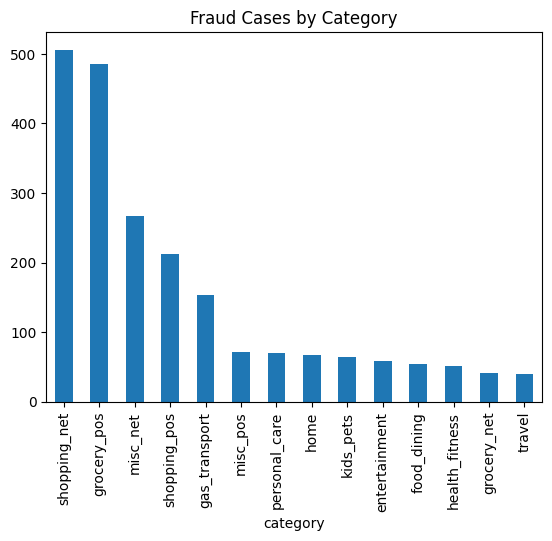

In [15]:
fraud_category['category'].value_counts().plot(
    kind='bar'
)

plt.title("Fraud Cases by Category")

plt.show()

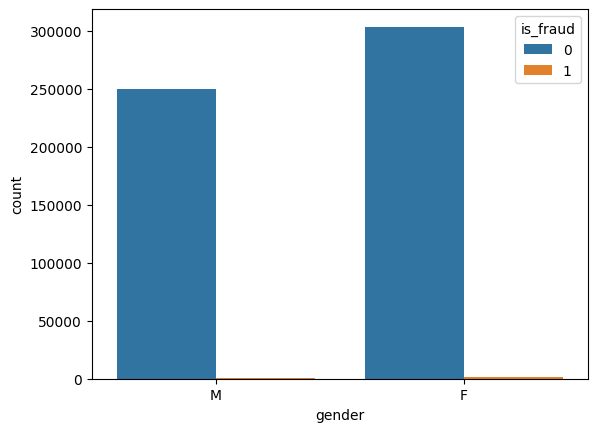

In [16]:
# Fraud by Gender
sns.countplot(
    x='gender',
    hue='is_fraud',
    data=df
)

plt.show()

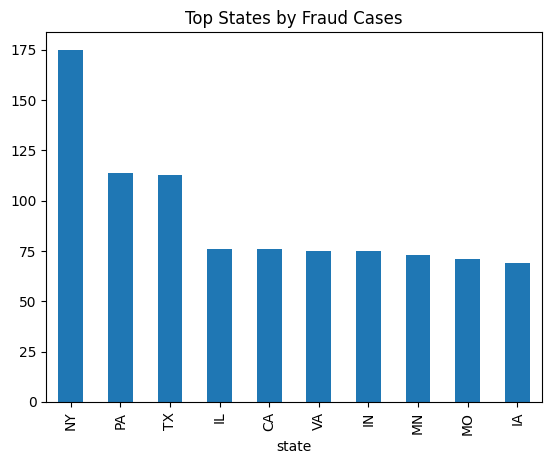

In [17]:
# Fraud by State
state_fraud = fraud_category['state'].value_counts().head(10)

state_fraud.plot(
    kind='bar'
)

plt.title("Top States by Fraud Cases")

plt.show()

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 555719 entries, 0 to 555718
Data columns (total 23 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Unnamed: 0             555719 non-null  int64  
 1   trans_date_trans_time  555719 non-null  object 
 2   cc_num                 555719 non-null  int64  
 3   merchant               555719 non-null  object 
 4   category               555719 non-null  object 
 5   amt                    555719 non-null  float64
 6   first                  555719 non-null  object 
 7   last                   555719 non-null  object 
 8   gender                 555719 non-null  object 
 9   street                 555719 non-null  object 
 10  city                   555719 non-null  object 
 11  state                  555719 non-null  object 
 12  zip                    555719 non-null  int64  
 13  lat                    555719 non-null  float64
 14  long                   555719 non-nu

In [20]:
drop_cols = [
    'Unnamed: 0',
    'trans_date_trans_time',
    'cc_num',
    'first',
    'last',
    'street',
    'trans_num'
]

df = df.drop(columns=drop_cols)

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 555719 entries, 0 to 555718
Data columns (total 16 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   merchant    555719 non-null  object 
 1   category    555719 non-null  object 
 2   amt         555719 non-null  float64
 3   gender      555719 non-null  object 
 4   city        555719 non-null  object 
 5   state       555719 non-null  object 
 6   zip         555719 non-null  int64  
 7   lat         555719 non-null  float64
 8   long        555719 non-null  float64
 9   city_pop    555719 non-null  int64  
 10  job         555719 non-null  object 
 11  dob         555719 non-null  object 
 12  unix_time   555719 non-null  int64  
 13  merch_lat   555719 non-null  float64
 14  merch_long  555719 non-null  float64
 15  is_fraud    555719 non-null  int64  
dtypes: float64(5), int64(4), object(7)
memory usage: 67.8+ MB


In [22]:
df['is_fraud'].unique()

array([0, 1])

In [23]:
df = df.dropna(subset=['is_fraud'])

In [24]:
X = df.drop('is_fraud', axis=1)
y = df['is_fraud']

In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [26]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in X.select_dtypes(include='object').columns:
    X[col] = le.fit_transform(X[col].astype(str))

In [27]:
X.select_dtypes(include='object').columns

Index([], dtype='object')

In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [29]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [30]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    max_iter=1000,
    class_weight='balanced'
)

lr.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [31]:
lr_pred = lr.predict(X_test)

In [32]:
print(classification_report(y_test, lr_pred))

              precision    recall  f1-score   support

           0       1.00      0.94      0.97    110715
           1       0.04      0.74      0.08       429

    accuracy                           0.94    111144
   macro avg       0.52      0.84      0.53    111144
weighted avg       1.00      0.94      0.96    111144



In [33]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(
    random_state=42
)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

print(classification_report(y_test, dt_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    110715
           1       0.59      0.64      0.61       429

    accuracy                           1.00    111144
   macro avg       0.79      0.82      0.81    111144
weighted avg       1.00      1.00      1.00    111144



In [34]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(
    n_neighbors=5
)

knn.fit(X_train, y_train)

knn_pred = knn.predict(X_test)

print(classification_report(y_test, knn_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    110715
           1       0.71      0.38      0.50       429

    accuracy                           1.00    111144
   macro avg       0.86      0.69      0.75    111144
weighted avg       1.00      1.00      1.00    111144



In [35]:
results = pd.DataFrame({
    'Model':[
        'Logistic Regression',
        'Decision Tree',
        'KNN'
    ],

    'Precision':[
        0.03,
        0.61,
        0.69
    ],

    'Recall':[
        0.80,
        0.64,
        0.41
    ],

    'F1 Score':[
        0.06,
        0.62,
        0.52
    ]
})

results

,Model,Precision,Recall,F1 Score
0,Logistic Regression,0.03,0.80,0.06
1,Decision Tree,0.61,0.64,0.62
2,KNN,0.69,0.41,0.52


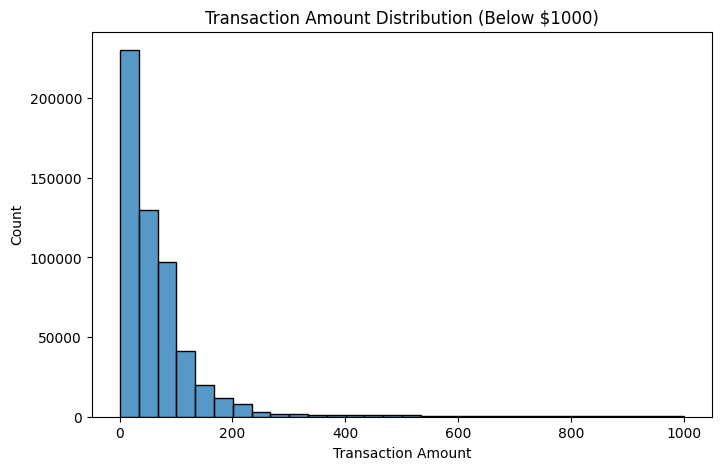

In [36]:
plt.figure(figsize=(8,5))

sns.histplot(df[df['amt'] < 1000]['amt'], bins=30)

plt.title("Transaction Amount Distribution (Below $1000)")
plt.xlabel("Transaction Amount")

plt.show()

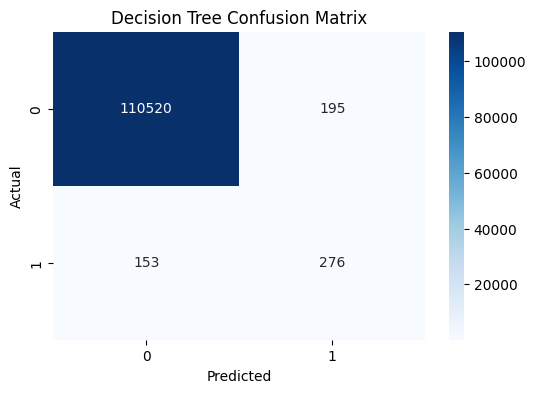

In [37]:


cm = confusion_matrix(y_test, dt_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Decision Tree Confusion Matrix')

plt.show()